<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Tugas_dari_Hands_On_STA1542_Minggu_2_Kecenderungan_Deret_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu dinyatakan sebagai

$$Y_t=\mu_t+X_t,$$

Dengan $E(X_t)=0$ untuk semua $t$. Fungsi nilaitengah $\mu_t$ menggambarkan pola sistematis/rataan deret, sedangkan $X_t$ menggambarkan variasi acak.

Pada hands-on ini kita membedakan beberapa bentuk kecenderungan: **linear, kuadratik, musiman**, serta **linear + musiman**. Setelah model dipasang, residual diperiksa untuk melihat apakah masih terdapat pola yang belum dijelaskan.


## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [41]:
# Simulasi deret dengan kecenderungan linear
np.random.seed(1033)
n = 100
t = np.arange(n)

# Parameter SEBENARNYA yang digunakan untuk simulasi
beta0 = 33+10.0       # intersep
beta1 = 33+0.5        # slope
sigma = 2.0        # simpangan baku noise

trend = beta0 + beta1*t
noise = np.random.normal(loc=0, scale=sigma, size=n)
time_series = trend + noise

df = pd.DataFrame({
    'Time': pd.date_range(start='2017-01-01', periods=n, freq='ME'),
    'Value': time_series
})


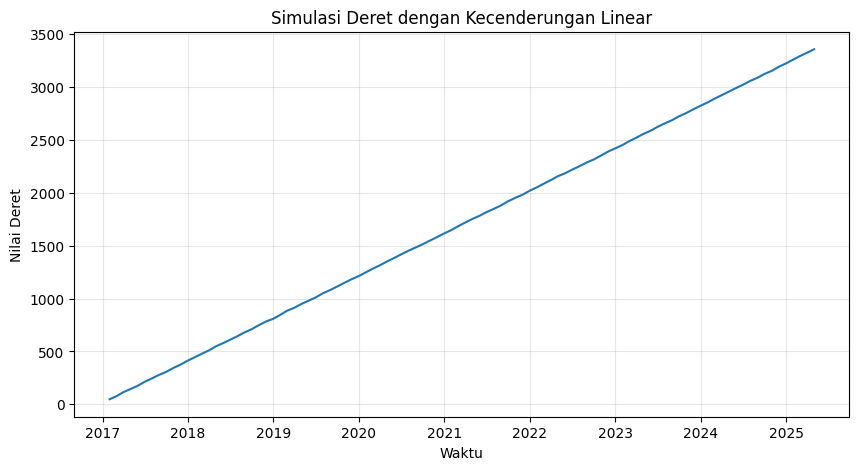

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"])
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret dengan Kecenderungan Linear")
plt.grid(alpha=0.3)
plt.show()


Cek apakah ada korelasi antar pengamatan?

Ketika nilai koefisien tren β₁ diubah dari 0,5 menjadi 33,5, terjadi peningkatan kemiringan tren yang sangat besar, sedangkan standar deviasi white noise tetap sebesar 2.

Perbandingan antara standar deviasi white noise dan kenaikan tren setiap periode adalah

$$ \frac{\sigma_\varepsilon}{\beta_1} =\frac{2}{33,5} \approx 0,060. $$

Artinya, standar deviasi white noise hanya sekitar 6% dari besarnya kenaikan tren pada setiap periode. Kondisi tersebut menyebabkan variasi acak relatif kecil dibandingkan dengan perubahan tren, sehingga fluktuasi akibat white noise menjadi kurang terlihat secara visual dan deret waktu tampak hampir membentuk garis lurus dengan kecenderungan meningkat yang sangat kuat.

In [43]:
# Ubah waktu menjadi indeks numerik agar dapat digunakan dalam regresi
df["Time_Numeric"] = np.arange(len(df))
correlation = df["Time_Numeric"].corr(df["Value"])
print(f"Korelasi antara waktu dan nilai: {correlation:.4f}")


Korelasi antara waktu dan nilai: 1.0000


In [44]:
X = sm.add_constant(df["Time_Numeric"])
Y = df["Value"]
model = sm.OLS(Y, X).fit()
print(model.summary())
print("\nParameter sebenarnya : beta0 = 10.0, beta1 = 0.5")
print(f"Parameter estimasi   : beta0 = {model.params.iloc[0]:.4f}, beta1 = {model.params.iloc[1]:.4f}")


                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.100e+07
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          4.90e-263
Time:                        02:51:37   Log-Likelihood:                -215.55
No. Observations:                 100   AIC:                             435.1
Df Residuals:                      98   BIC:                             440.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           43.3100      0.419    103.406   

### Interpretasi hasil pengepasan

Koefisien OLS diperoleh dari data, sedangkan $beta_0=43$ dan $beta_1=33.5$ adalah parameter yang **sengaja ditentukan ketika simulasi**. Karena noise dibangkitkan secara acak dengan simpangan baku 2, koefisien hasil estimasi tidak harus persis sama dengan parameter sebenarnya, tetapi diharapkan berada di dekatnya.

Nilai $R^2$ yang tinggi menunjukkan bahwa variasi nilai deret banyak dijelaskan oleh kecenderungan waktu. Namun, kualitas model tidak cukup dinilai dari $R^2$ saja; residual tetap perlu diperiksa.


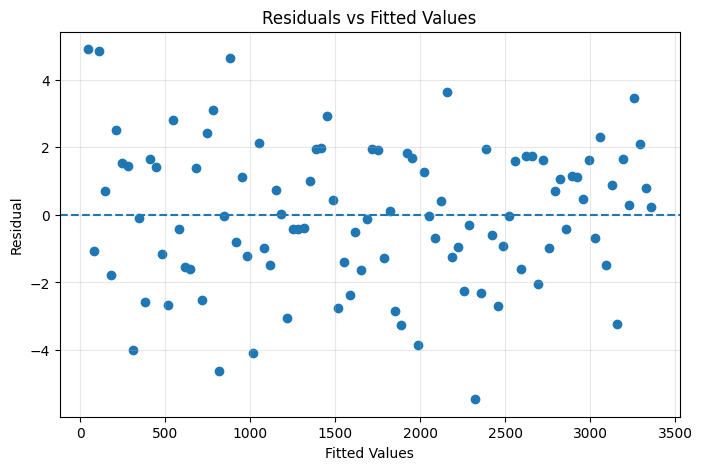

In [45]:
# Residual vs fitted values
plt.figure(figsize=(8,5))
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residual')
plt.title('Residuals vs Fitted Values')
plt.grid(alpha=0.3)
plt.show()


### Interpretasi Residuals vs Fitted

Berdasarkan plot Residuals vs Fitted Values, residual tersebar secara acak di sekitar garis nol dan tidak menunjukkan pola sistematis maupun pola melengkung. Selain itu, penyebaran residual relatif konstan pada berbagai nilai fitted values sehingga tidak terlihat indikasi heteroskedastisitas. Plot ini merupakan **diagnosis visual**, sehingga keputusan akhir mengenai asumsi perlu didukung oleh uji statistik.


In [46]:
# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"LM Statistic : {bp_test[0]:.4f}")
print(f"LM p-value   : {bp_test[1]:.4f}")
print(f"F Statistic  : {bp_test[2]:.4f}")
print(f"F p-value    : {bp_test[3]:.4f}")
if bp_test[1] > 0.05:
    print("Kesimpulan: tidak ada bukti heteroskedastisitas pada taraf 5%.")
else:
    print("Kesimpulan: terdapat bukti heteroskedastisitas pada taraf 5%.")


LM Statistic : 4.2586
LM p-value   : 0.0391
F Statistic  : 4.3591
F p-value    : 0.0394
Kesimpulan: terdapat bukti heteroskedastisitas pada taraf 5%.


### Kesimpulan Breusch-Pagan

Hipotesis nol Breusch-Pagan adalah **varian residual konstan (homoskedastisitas)**. Jika $p$-value $>0.05$, $H_0$ gagal ditolak sehingga tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas. Jika $p$-value $\leq0.05$, terdapat indikasi heteroskedastisitas.

Besarnya slope $beta_1$ tidak dengan sendirinya menyebabkan heteroskedastisitas. Heteroskedastisitas berkaitan dengan perubahan ragam residual terhadap level/prediktor.


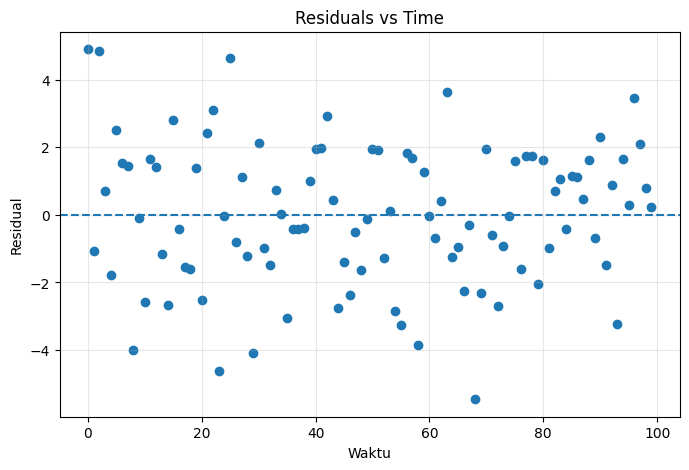

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(df["Time_Numeric"], model.resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Waktu')
plt.ylabel('Residual')
plt.title('Residuals vs Time')
plt.grid(alpha=0.3)
plt.show()


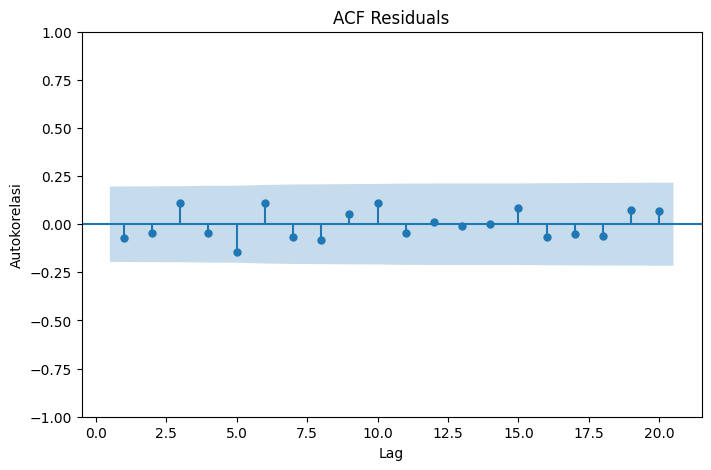

In [48]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(8,5))
plot_acf(model.resid, lags=20, zero=False, ax=ax)
ax.set_title('ACF Residuals')
ax.set_xlabel('Lag')
ax.set_ylabel('Autokorelasi')
plt.show()


## Apa yang dapat Anda simpulkan dari plot di atas?


### Interpretasi residual vs time dan ACF

Plot Residuals vs Time Titik residual tersebar di sekitar garis nol dan tidak adanya indikasi kuat pola sistematis pada residual. Hal ini mendukung asumsi bahwa model linear sudah cukup sesuai dan secara visual residual memiliki varians yang relatif konstan. Plot ACF Residual Batang ACF pada lag 1–20 seluruhnya berada di dalam batas interval kepercayaan (area biru). Artinya tidak ada lag yang menunjukkan autokorelasi yang signifikan secara visual.

Perlu dibedakan antara **diagnosis visual** dan **uji formal**; karena itu digunakan Ljung--Box berikut.


In [49]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)
# Menampilkan lag yang signifikan
significant_lag = ljung_box_test[
    ljung_box_test['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)

Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.506068   0.476846
2    0.722209   0.696906
3    2.019500   0.568369
4    2.216753   0.695963
5    4.526634   0.476328
6    5.887750   0.435881
7    6.375381   0.496664
8    7.109687   0.524846
9    7.419169   0.593564
10   8.801569   0.551033
11   9.062115   0.616159
12   9.074790   0.696529
13   9.087322   0.766317
14   9.087352   0.825414
15   9.962655   0.822082
16  10.537303   0.837105
17  10.851163   0.864196
18  11.293204   0.881503
19  11.951635   0.887682

Kesimpulan: Tidak terdapat autokorelasi residual.


### Kesimpulan Ljung--Box

Ljung--Box menguji $H_0$: tidak terdapat autokorelasi residual secara bersama-sama sampai lag tertentu. Interpretasi dilakukan dari **p-value pada setiap lag**. Jika p-value $>0.05$, tidak ada bukti yang cukup untuk menolak $H_0$ pada lag tersebut.

Untuk residual yang benar-benar menyerupai white noise, diharapkan tidak ada pola autokorelasi yang sistematis pada berbagai lag.


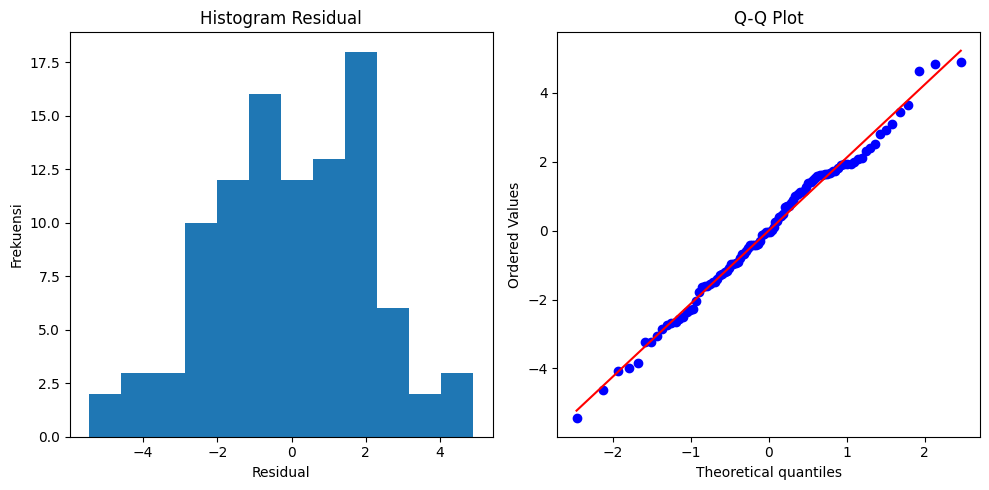

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(model.resid, bins=12)
axes[0].set_title('Histogram Residual')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frekuensi')
stats.probplot(model.resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()


### Interpretasi histogram dan Q-Q plot

Histogram yang relatif simetris dan Q-Q plot yang titik-titiknya mengikuti garis referensi mendukung asumsi normalitas secara visual. Penyimpangan pada bagian ekor masih dapat terjadi karena ukuran sampel dan variasi acak.


In [51]:
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Statistic : {shapiro_stat:.4f}")
print(f"P-value   : {shapiro_p_value:.4f}")
if shapiro_p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi norma.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")


Statistic : 0.9914
P-value   : 0.7752
Kesimpulan: Residual berdistribusi norma.


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Hasil uji Shapiro Wilk menunjukan p-value diatas 0,05 atau tidak signifikan untuk menolak hipotesis Nol. Hasil ini konsisten dengan histogram dan Q-Q plot, yang menunjukkan bahwa residual secara umum mengikuti pola distribusi normal. Oleh karena itu, asumsi normalitas residual dapat dianggap terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [52]:
# Simulasi kecenderungan kuadratik
np.random.seed(1033)
n_periods = 120
time = np.arange(n_periods)

# Parameter sebenarnya
beta0 = 33+10.0
beta1 = 33+0.5
beta2 = 33+0.02
sigma = 10.0

quadratic_component = beta0 + beta1*time + beta2*time**2
noise = np.random.normal(0, sigma, n_periods)
data = quadratic_component + noise

dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='ME')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})


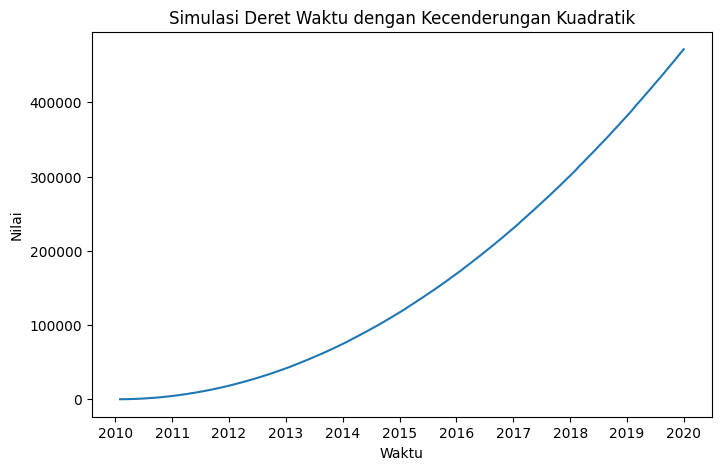

In [53]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

### Interpretasi deret kuadratik

Berdasarkan plot, deret menunjukkan pola kecenderungan meningkat yang bersifat kuadratik. Nilai deret meningkat dari waktu ke waktu dan laju peningkatannya semakin besar. Hal ini terlihat dari bentuk kurva yang semakin curam pada periode-periode akhir. Selain kecenderungan meningkat tersebut, terdapat fluktuasi acak di sekitar kecenderungan utama yang berasal dari komponen noise ε
t. Namun, karena skala komponen kuadratik sangat besar dibandingkan dengan standar deviasi noise sebesar 10 sehingga grafik hampir mulus secara visual.

In [54]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.098e+10
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:51:38   Log-Likelihood:                -450.71
No. Observations:                 120   AIC:                             907.4
Df Residuals:                     117   BIC:                             915.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.4652      2.823     16.812      0.0

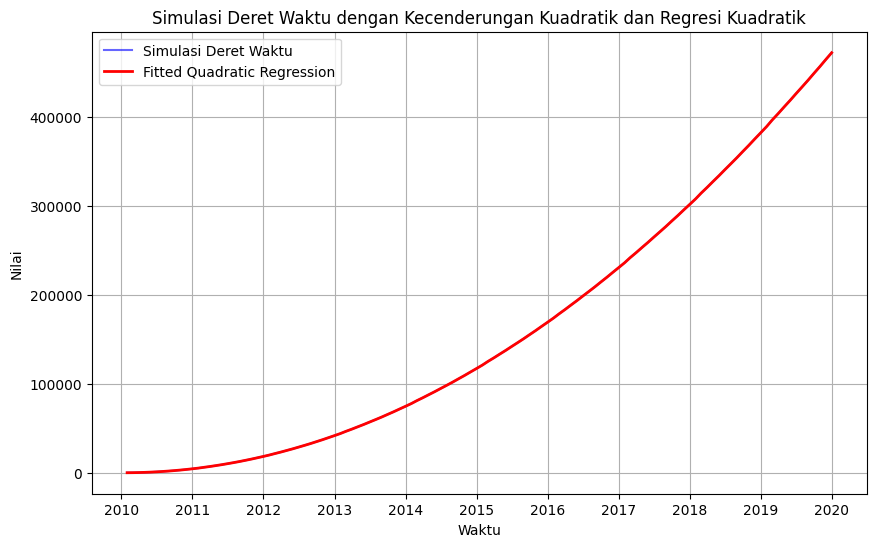

In [55]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

### Apakah model kuadratik tepat?

Berdasarkan plot, garis fitted quadratic regression hampir berimpit dengan pola deret yang sebenarnya. Nilai Rsquare dan Adj-Rsquare menunjukkan bahwa hampir seluruh variasi y dapat dijelaskan oleh komponen waktu linear dan kuadratik. NIlai R2 sangat tinggi karena parameter pada beta 2 dibandingkan noise 10 sehingga komponen kuadratik menjadi sangat dominan sehingga fluktuasi noise relatif kecil pada skala grafik.

In [56]:
# cek asumsi model regresi kuadratik
# 1. UJI HETEROSKEDASTISITAS
#    Breusch-Pagan Test

bp_test = het_breuschpagan(
    model_quad.resid,
    model_quad.model.exog
)

print("\n================================================")
print("UJI BREUSCH-PAGAN")
print("================================================")

print(f"LM Statistic : {bp_test[0]:.4f}")
print(f"LM P-value   : {bp_test[1]:.4f}")
print(f"F Statistic  : {bp_test[2]:.4f}")
print(f"F P-value    : {bp_test[3]:.4f}")

if bp_test[1] > 0.05:
    print("Kesimpulan: Tidak terdapat heteroskedastisitas.")
else:
    print("Kesimpulan: Terdapat indikasi heteroskedastisitas.")



UJI BREUSCH-PAGAN
LM Statistic : 4.5079
LM P-value   : 0.1050
F Statistic  : 2.2834
F P-value    : 0.1065
Kesimpulan: Tidak terdapat heteroskedastisitas.


In [57]:
# 2. UJI AUTOKORELASI
#    Ljung-Box Test

ljung_box_test = acorr_ljungbox(
    model_quad.resid,
    lags=range(1, 20),
    return_df=True
)

print("\n================================================")
print("UJI LJUNG-BOX")
print("================================================")

print(ljung_box_test)

# Menampilkan lag yang signifikan
significant_lag = ljung_box_test[
    ljung_box_test['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)




UJI LJUNG-BOX
      lb_stat  lb_pvalue
1    2.875041   0.089963
2    3.195415   0.202360
3    5.095404   0.164943
4    5.960928   0.202085
5    8.036859   0.154216
6    8.789961   0.185740
7   10.076199   0.184296
8   10.303321   0.244379
9   10.322033   0.325049
10  10.529444   0.395333
11  10.546183   0.482027
12  10.905752   0.537013
13  11.371065   0.579763
14  11.492092   0.647019
15  12.459262   0.643986
16  13.378689   0.644894
17  13.642612   0.692219
18  14.925848   0.667052
19  15.735534   0.674844

Kesimpulan: Tidak terdapat autokorelasi residual.


In [58]:
# 3. UJI NORMALITAS RESIDUAL
#    Shapiro-Wilk Test

shapiro_stat, shapiro_p_value = stats.shapiro(model_quad.resid)

print("\n================================================")
print("UJI SHAPIRO-WILK")
print("================================================")

print(f"Statistic : {shapiro_stat:.4f}")
print(f"P-value   : {shapiro_p_value:.4f}")

if shapiro_p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")


UJI SHAPIRO-WILK
Statistic : 0.9894
P-value   : 0.4829
Kesimpulan: Residual berdistribusi normal.


In [59]:
# 9. RINGKASAN HASIL UJI ASUMSI
print("\n================================================")
print("RINGKASAN UJI ASUMSI")
print("================================================")

print(f"Breusch-Pagan p-value : {bp_test[1]:.4f}")
print(f"Ljung-Box minimum p-value : {ljung_box_test['lb_pvalue'].min():.4f}")
print(f"Shapiro-Wilk p-value  : {shapiro_p_value:.4f}")


RINGKASAN UJI ASUMSI
Breusch-Pagan p-value : 0.1050
Ljung-Box minimum p-value : 0.0900
Shapiro-Wilk p-value  : 0.4829


## Kecenderungan Musiman/Siklik

Misalkan fungsi nilaitengah musiman dinyatakan sebagai

$$\mu_t=beta_0+beta_1\cos(2\pi f t)+beta_2\sin(2\pi f t),$$

Dengan periode musiman $s$, frekuensi adalah $f=1/s$. Untuk data bulanan dengan pola tahunan, $s=12$ sehingga $f=1/12$. Model tersebut merupakan **regresi harmonik**. Bentuk sinus dan kosinus bersama-sama memungkinkan model menangkap amplitudo dan fase pola musiman.

Alternatif lain adalah menggunakan dummy musiman, yaitu satu parameter untuk setiap kategori musim/bulan.


In [60]:
np.random.seed(1033)
n_periods = 120
time = np.arange(n_periods)

# Parameter sebenarnya
beta0 = 55+33
beta_cos = -25+33
beta_sin = -2+33
freq = 1/12
sigma = 2.0

seasonal_component = (
    beta0
    + beta_cos*np.cos(2*np.pi*time*freq)
    + beta_sin*np.sin(2*np.pi*time*freq)
)
noise = np.random.normal(0, sigma, n_periods)
data = seasonal_component + noise
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='ME')
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


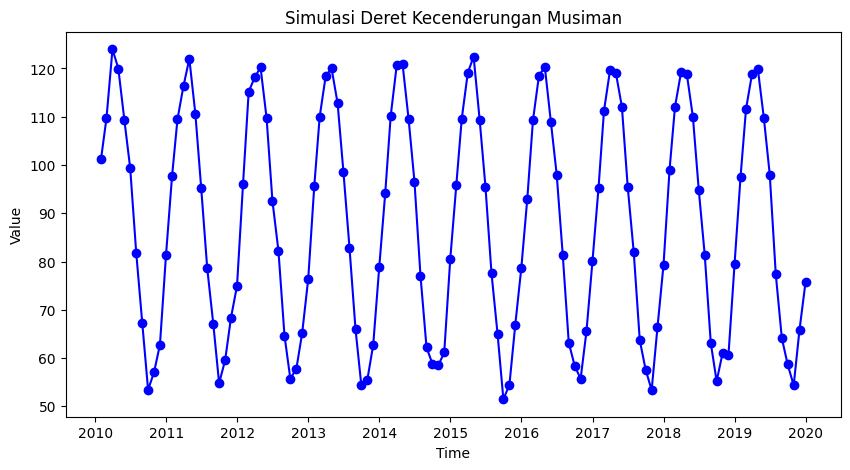

In [61]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


### Interpretasi pola musiman

Model Deret Musiman:
$$ Y_t=\beta_0+\beta_1\cos(2\pi t/12)+ \beta_2\sin(2\pi t/12)+\varepsilon_t. $$
Pada data simulasi model menjadi:
$$ Y_t= 88+ 8\cos\left(\frac{2\pi t}{12}\right) + 31\sin\left(\frac{2\pi t}{12}\right) +\varepsilon_t. $$

Amplitudo pola musiman adalah

$$A=\sqrt{8^2+31^2} = 32.02.$$

Jadi nilai tengah teoritis berfluktuasi sekitar $88\pm32.02$, yaitu kira-kira 55.98 sampai 120.02. Pola tersebut berulang setiap 12 bulan, sementara tidak ada komponen tren jangka panjang. Karena amplitudo absolutnya relatif konstan dari tahun ke tahun, struktur ini bersifat **aditif**.


In [62]:
print("Jumlah observasi:", len(df_seasonal))
print("Periode musiman:", 1/freq)

df_seasonal["Year"] = df_seasonal["Date"].dt.year

print(df_seasonal.groupby("Year").size())

Jumlah observasi: 120
Periode musiman: 12.0
Year
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
dtype: int64


In [63]:
from statsmodels.tsa.deterministic import Seasonality
musim = Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns = ['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']


In [64]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [65]:
# Model dummy musiman tanpa intercept: 12 dummy, satu koefisien per bulan
musiman = sm.OLS(df_seasonal['Value'], musim).fit()
print(musiman.summary())


                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     1355.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          2.74e-110
Time:                        02:51:39   Log-Likelihood:                -251.75
No. Observations:                 120   AIC:                             527.5
Df Residuals:                     108   BIC:                             560.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       96.5556      0.657    146.902      0.0

### Interpretasi regresi dummy musiman tanpa intercept

Karena model **tidak memiliki intercept** dan memiliki 12 dummy bulan, setiap koefisien langsung merupakan estimasi **rataan untuk bulan tersebut**. Misalnya koefisien Januari adalah estimasi rataan Januari, koefisien Februari adalah estimasi rataan Februari, dan seterusnya.

Model ini berbeda dari model harmonik: dummy tidak memaksakan bentuk sinusoidal, sehingga setiap bulan dapat mempunyai rataan sendiri.


In [66]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence = musiman.get_influence()
std_resid = influence.resid_studentized_internal
mapping = {1:'J',2:'F',3:'M',4:'A',5:'M',6:'J',7:'J',8:'A',9:'S',10:'O',11:'N',12:'D'}


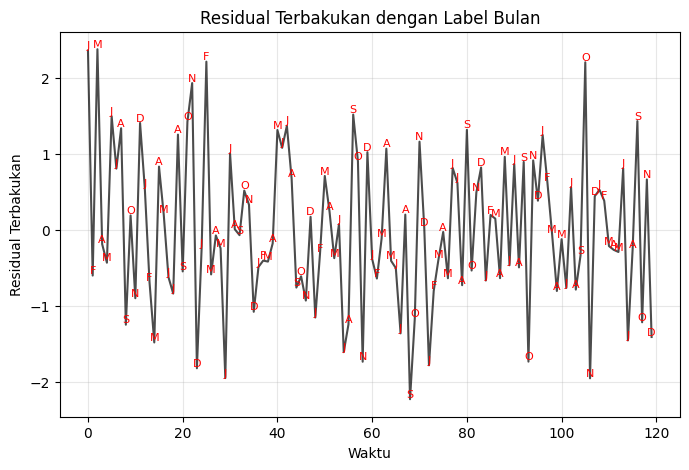

In [67]:
plt.figure(figsize=(8,5))

# Plot the residual line first
plt.plot(range(len(std_resid)), std_resid, color='black', alpha=0.7)

# Add month initials as text labels for each point
for i in range(len(std_resid)):
    month_initial = mapping[i%12+1]
    plt.text(i, std_resid[i], month_initial, ha='center', va='bottom', fontsize=8, color='red')

plt.xlabel('Waktu')
plt.ylabel('Residual Terbakukan')
plt.title('Residual Terbakukan dengan Label Bulan') # Added a more descriptive title
plt.grid(alpha=0.3) # Added a grid for better readability
plt.show()

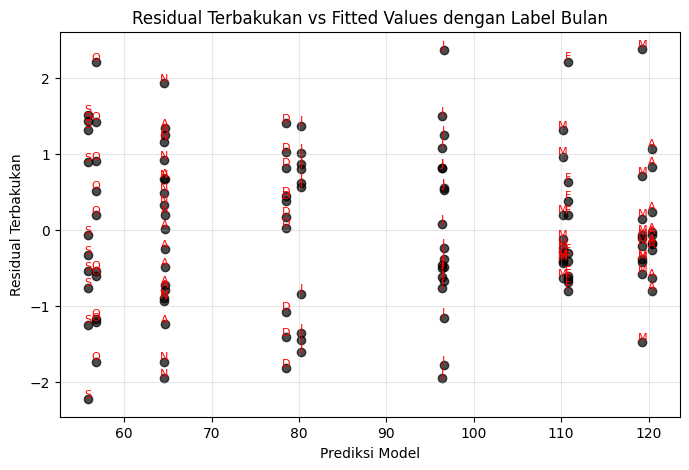

In [68]:
plt.figure(figsize=(8,5))

# Plot the scatter points first
plt.scatter(musiman.fittedvalues.values, std_resid, color='black', alpha=0.7)

# Add month initials as text labels for each point
for i in range(len(std_resid)):
  month_initial = mapping[i%12+1]
  plt.text(musiman.fittedvalues.values[i],
           std_resid[i],
           month_initial,
           ha='center', va='bottom', fontsize=8, color='red')

plt.xlabel('Prediksi Model')
plt.ylabel('Residual Terbakukan')
plt.title('Residual Terbakukan vs Fitted Values dengan Label Bulan')
plt.grid(alpha=0.3)
plt.show()

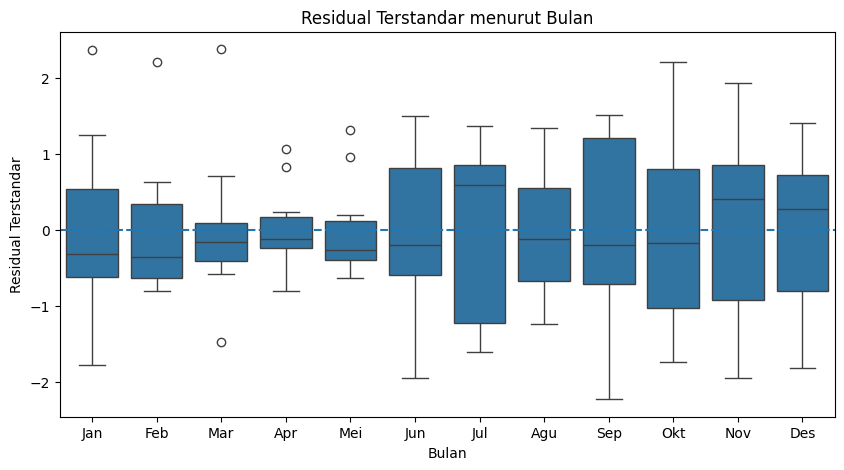

In [69]:
import seaborn as sns
bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'] * 10
box_sisaan = pd.DataFrame({'bulan': bulan[:len(std_resid)], 'sisaan': std_resid})
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan', y='sisaan', data=box_sisaan)
plt.axhline(0, linestyle='--')
plt.xlabel('Bulan')
plt.ylabel('Residual Terstandar')
plt.title('Residual Terstandar menurut Bulan')
plt.show()

### Interpretasi tiga plot residual

1. **Residual vs waktu**: digunakan untuk melihat pola sistematis atau perubahan ragam sepanjang waktu.
2. **Residual vs fitted**: digunakan untuk melihat ketidaklinieran dan perubahan ragam residual.
3. **Boxplot residual menurut bulan**: membantu melihat apakah residual cenderung berbeda atau memiliki penyebaran berbeda antarbulan.

Tidak adanya pola yang jelas mendukung kecukupan model, tetapi uji formal tetap diperlukan.


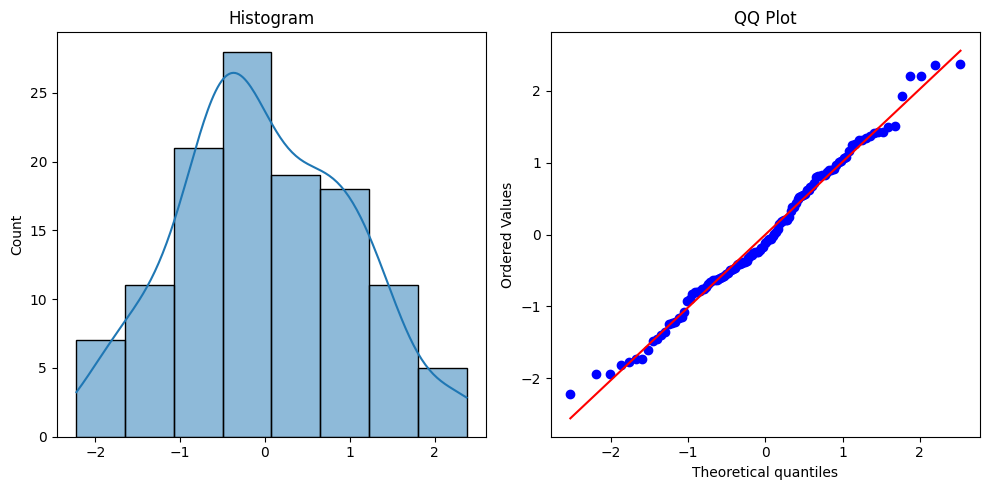

In [70]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

### Apakah model sudah tepat?

Ketepatan model tidak ditentukan hanya dari satu plot. Model dikatakan memadai apabila residual tidak menunjukkan autokorelasi, ragam relatif konstan, dan distribusinya cukup sesuai dengan asumsi yang diperlukan. Karena model dummy tanpa intercept menggunakan 12 parameter musiman, kita juga perlu memastikan interpretasi koefisiennya sesuai dengan tujuan analisis.


In [71]:
# Uji asumsi model dummy musiman tanpa intercept
# Heteroskedastisitas, autokorelasi, dan normalitas residual


In [73]:
import statsmodels.api as sm
# 1. UJI HETEROSKEDASTISITAS
exog_bp_test = sm.add_constant(musiman.model.exog, prepend=True)

bp_test = het_breuschpagan(
    musiman.resid,
    exog_bp_test
)
print("UJI BREUSCH-PAGAN")
print(f"LM Statistic : {bp_test[0]:.4f}")
print(f"LM P-value   : {bp_test[1]:.4f}")
print(f"F Statistic  : {bp_test[2]:.4f}")
print(f"F P-value    : {bp_test[3]:.4f}")

if bp_test[1] > 0.05:
    print("Kesimpulan: Tidak terdapat heteroskedastisitas.")
else:
    print("Kesimpulan: Terdapat indikasi heteroskedastisitas.")


UJI BREUSCH-PAGAN
LM Statistic : 11.5599
LM P-value   : 0.4816
F Statistic  : 1.0466
F P-value    : 0.4114
Kesimpulan: Tidak terdapat heteroskedastisitas.


In [77]:
ljung_box_test = acorr_ljungbox(
    musiman.resid,
    lags=range(1, 20),
    return_df=True
)
print(ljung_box_test)
# Menampilkan lag yang signifikan
significant_lag = ljung_box_test[
    ljung_box_test['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)


      lb_stat  lb_pvalue
1    4.235719   0.039582
2    4.420304   0.109684
3    5.526616   0.137055
4    5.794625   0.215020
5    6.018312   0.304441
6    7.594190   0.269366
7    7.711085   0.358758
8    7.719057   0.461383
9    7.723510   0.562232
10   8.084891   0.620545
11   8.137360   0.700949
12  11.599377   0.478366
13  11.836270   0.541113
14  11.849111   0.618419
15  12.340510   0.653094
16  12.580666   0.703135
17  12.745056   0.753079
18  13.085616   0.786462
19  16.242905   0.641015

Kesimpulan: Terdapat indikasi autokorelasi pada:
    lb_stat  lb_pvalue
1  4.235719   0.039582


In [79]:
shapiro_stat_dummy, shapiro_p_dummy = stats.shapiro(musiman.resid)
print('SHAPIRO-WILK')
print(f'Statistic: {shapiro_stat_dummy:.4f}')
print(f'P-value  : {shapiro_p_dummy:.4f}')
if shapiro_p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

SHAPIRO-WILK
Statistic: 0.9878
P-value  : 0.3580
Kesimpulan: Residual berdistribusi normal.


In [80]:
# Model dengan intercept: gunakan 11 dummy dan jadikan Januari sebagai kategori referensi
musiman_int = sm.OLS(
    df_seasonal['Value'],
    sm.add_constant(musim.iloc[:, 1:])
).fit()


In [81]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     1355.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          2.74e-110
Time:                        02:54:34   Log-Likelihood:                -251.75
No. Observations:                 120   AIC:                             527.5
Df Residuals:                     108   BIC:                             560.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.5556      0.657    146.902      0.0

### Model dummy dengan intercept vs tanpa intercept

Pada model **tanpa intercept + 12 dummy**, setiap koefisien adalah rataan masing-masing bulan.

Pada model **dengan intercept + 11 dummy**, satu bulan menjadi kategori referensi. Intercept merupakan rataan bulan referensi (Januari), sedangkan koefisien bulan lain menunjukkan **selisih rataan bulan tersebut terhadap Januari**.

Kedua parameterisasi dapat menghasilkan nilai fitted yang sama apabila spesifikasinya ekuivalen. Perbedaannya terutama pada cara koefisien diinterpretasikan.

In [82]:
# Uji asumsi model dengan intercept


In [84]:
bp_test_int = het_breuschpagan(musiman_int.resid, musiman_int.model.exog)
print('BREUSCH-PAGAN - MODEL DENGAN INTERCEPT')
print(f'LM p-value: {bp_test_int[1]:.4f}')
print(f'F  p-value: {bp_test_int[3]:.4f}')
if bp_test_int[1] > 0.05:
    print("Kesimpulan: Tidak terdapat heteroskedastisitas.")
else:
    print("Kesimpulan: Terdapat indikasi heteroskedastisitas.")

BREUSCH-PAGAN - MODEL DENGAN INTERCEPT
LM p-value: 0.3976
F  p-value: 0.4114
Kesimpulan: Tidak terdapat heteroskedastisitas.


In [86]:
lb_int = acorr_ljungbox(musiman_int.resid, lags=range(1,20), return_df=True)
print('LJUNG-BOX - MODEL DENGAN INTERCEPT')
print(lb_int)
# Menampilkan lag yang signifikan
significant_lag = lb_int[
    lb_int['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)

LJUNG-BOX - MODEL DENGAN INTERCEPT
      lb_stat  lb_pvalue
1    4.235719   0.039582
2    4.420304   0.109684
3    5.526616   0.137055
4    5.794625   0.215020
5    6.018312   0.304441
6    7.594190   0.269366
7    7.711085   0.358758
8    7.719057   0.461383
9    7.723510   0.562232
10   8.084891   0.620545
11   8.137360   0.700949
12  11.599377   0.478366
13  11.836270   0.541113
14  11.849111   0.618419
15  12.340510   0.653094
16  12.580666   0.703135
17  12.745056   0.753079
18  13.085616   0.786462
19  16.242905   0.641015

Kesimpulan: Terdapat indikasi autokorelasi pada:
    lb_stat  lb_pvalue
1  4.235719   0.039582


In [88]:
shapiro_stat_int, shapiro_p_int = stats.shapiro(musiman_int.resid)
print('SHAPIRO-WILK - MODEL DENGAN INTERCEPT')
print(f'Statistic: {shapiro_stat_int:.4f}')
print(f'P-value  : {shapiro_p_int:.4f}')
if shapiro_p_int > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

SHAPIRO-WILK - MODEL DENGAN INTERCEPT
Statistic: 0.9878
P-value  : 0.3580
Kesimpulan: Residual berdistribusi normal.


## Kecenderungan Linear dan Musiman

In [91]:
# Simulasi tren linear + seasonal sinusoidal (model aditif)
np.random.seed(1033)
n = 100
x = np.arange(n)

# Parameter sebenarnya
beta0 = 33+10.0
beta_trend = 33+0.5
amplitude = 5.0
sigma = 2.0

trend = beta0 + beta_trend*x
seasonality = amplitude*np.sin(2*np.pi*x/12)
noise = np.random.normal(scale=sigma, size=n)
series = trend + seasonality + noise

df_mix = pd.DataFrame({
    'Period': x,
    'Value': series,
    'Trend_Asli': trend,
    'Seasonal_Asli': seasonality,
    'Noise_Asli': noise
})


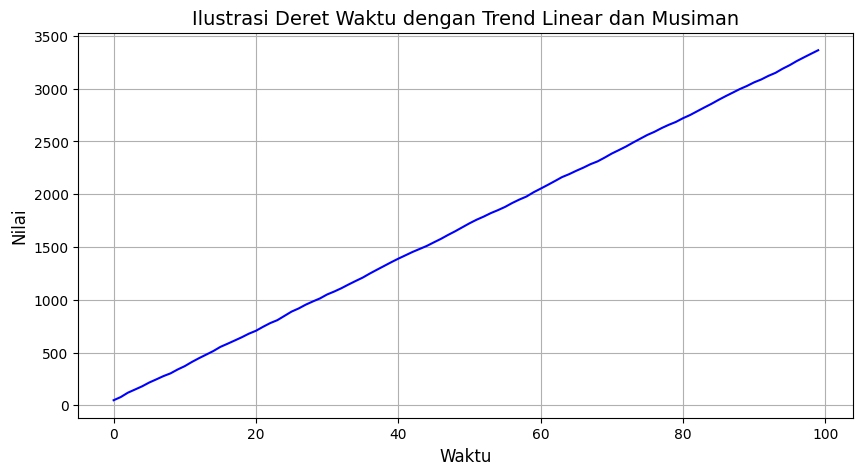

In [92]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.


In [97]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame({
    'Period': x,
    'Value': series,
    'Trend_Asli': trend,
    'Seasonal_Asli': seasonality,
    'Noise_Asli': noise
})
# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [98]:
season['period']=x

model_mix=sm.OLS(series,season).fit()


In [99]:
print(model_mix.summary())
print('\nParameter simulasi: beta0=10, beta_trend=0.5, cos=0, sin=5')
print('Parameter estimasi:')
print(model_mix.params)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.779e+06
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          6.32e-229
Time:                        03:00:50   Log-Likelihood:                -208.76
No. Observations:                 100   AIC:                             443.5
Df Residuals:                      87   BIC:                             477.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       43.8120      0.780     56.187      0.0

## Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?
Berdasarkan hasil estimasi model regresi tren dan musiman, diperoleh koefisien period sebesar 33,4922, yang sangat dekat dengan parameter simulasi sebesar 33,5. Hal ini menunjukkan bahwa model mampu mengestimasi komponen tren dengan baik. Koefisien period yang positif menunjukkan bahwa nilai deret waktu meningkat rata-rata sekitar 33,49 satuan untuk setiap kenaikan satu periode. Sementara itu, perbedaan koefisien dummy Januari hingga Desember menunjukkan adanya pola musiman bulanan. Pada data simulasi, komponen musiman dibangkitkan menggunakan fungsi sinus dengan koefisien sebesar 5 dan fungsi cosinus dengan koefisien 0, sehingga amplitudo musiman yang sebenarnya adalah 5 satuan. Dalam model dummy, komponen musiman tersebut direpresentasikan melalui perbedaan koefisien antarbulan.

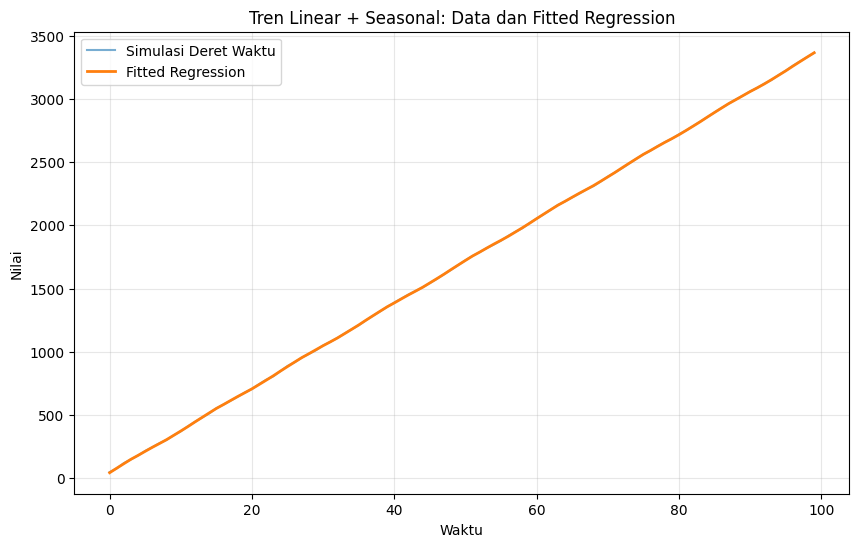

In [101]:
pred_mix = model_mix.predict(season)
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', linewidth=2)
plt.title('Tren Linear + Seasonal: Data dan Fitted Regression')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Pengecekan asumsi model tren + seasonal

Residual model diperiksa dengan tiga uji: **Breusch--Pagan** untuk heteroskedastisitas, **Ljung--Box** untuk autokorelasi, dan **Shapiro--Wilk** untuk normalitas. Interpretasi setiap uji menggunakan taraf signifikansi 5%.


In [107]:
exog_bp_test = sm.add_constant(model_mix.model.exog, prepend=True)

bp_mix = het_breuschpagan(
    model_mix.resid,
    exog_bp_test
)
print('BREUSCH-PAGAN')
print(f'LM p-value: {bp_mix[1]:.4f}')
print(f'F  p-value: {bp_mix[3]:.4f}')
if bp_mix[1] > 0.05:
    print("Kesimpulan: Tidak terdapat heteroskedastisitas.")
else:
    print("Kesimpulan: Terdapat indikasi heteroskedastisitas.")

BREUSCH-PAGAN
LM p-value: 0.3975
F  p-value: 0.3335
Kesimpulan: Tidak terdapat heteroskedastisitas.


In [110]:
lb_mix = acorr_ljungbox(resid_mix, lags=range(1,20), return_df=True)
print(lb_mix)
# Menampilkan lag yang signifikan
significant_lag = lb_mix[
    lb_mix['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)

      lb_stat  lb_pvalue
1    1.550525   0.213058
2    1.840738   0.398372
3    2.390711   0.495366
4    2.496719   0.645223
5    3.381498   0.641389
6    6.564340   0.363020
7    6.593115   0.472436
8    7.091385   0.526806
9    7.135182   0.623047
10   8.367630   0.592975
11   8.846911   0.636021
12  10.210800   0.597473
13  10.477806   0.654473
14  10.591858   0.717759
15  10.943703   0.756575
16  11.355282   0.787043
17  11.404031   0.834807
18  11.469762   0.873370
19  13.604139   0.806260

Kesimpulan: Tidak terdapat autokorelasi residual.


In [112]:
shapiro_stat_mix, shapiro_p_mix = stats.shapiro(resid_mix)
print('SHAPIRO-WILK')
print(f'Statistic: {shapiro_stat_mix:.4f}')
print(f'P-value  : {shapiro_p_mix:.4f}')
if shapiro_stat_mix > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

SHAPIRO-WILK
Statistic: 0.9840
P-value  : 0.2695
Kesimpulan: Residual berdistribusi normal.


## Dekomposisi Deret Waktu

Jika komponen deret belum jelas dari plot, dekomposisi dapat digunakan untuk memisahkan deret menjadi **trend, seasonal, dan residual**.

Untuk model **aditif**:

$$Y_t=T_t+S_t+R_t.$$

Untuk model **multiplikatif**:

$$Y_t=T_t	imes S_t	imes R_t.$$

Pemilihan aditif atau multiplikatif didasarkan terutama pada **hubungan amplitudo seasonal dengan level deret**, bukan semata-mata karena variansnya kecil atau besar. Jika amplitudo seasonal relatif konstan dalam satuan absolut, aditif lebih sesuai. Jika amplitudo seasonal membesar/mengecil mengikuti level deret, multiplikatif lebih sesuai.

Dekomposisi terutama digunakan untuk **eksplorasi struktur deret dan membantu memilih bentuk model**, bukan untuk secara otomatis menentukan satu-satunya model forecasting.


In [113]:
# Dekomposisi deret linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)


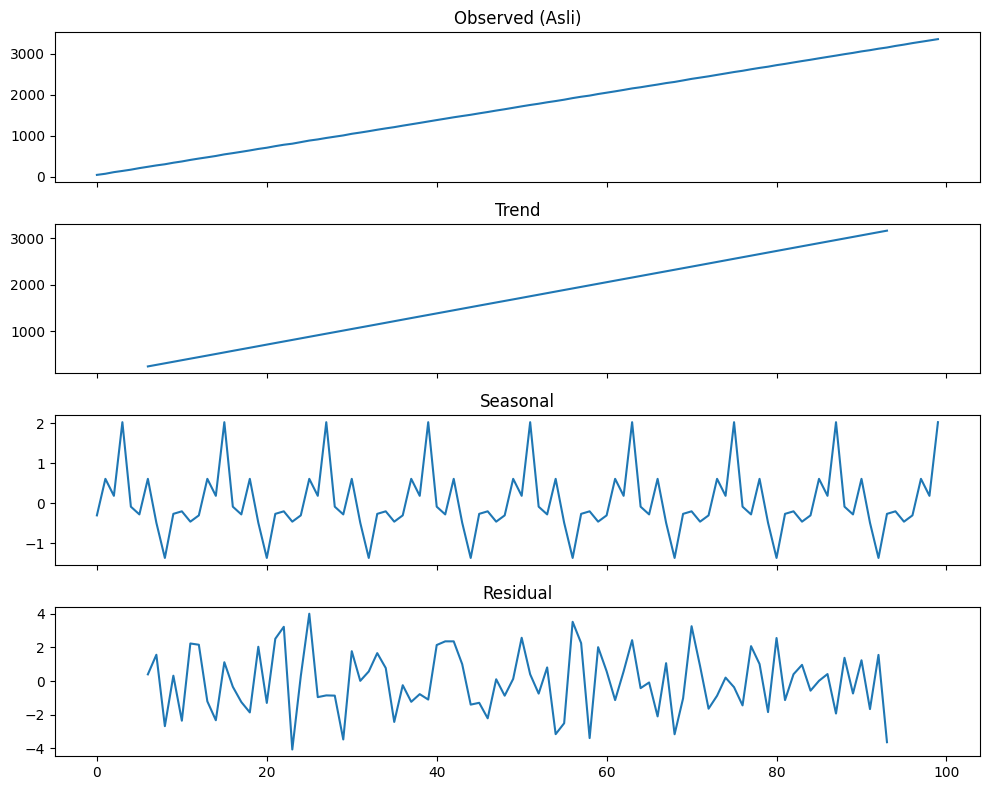

In [114]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

### Interpretasi dekomposisi deret linear

**Observed** menunjukkan deret yang meningkat. **Trend** memperlihatkan kecenderungan jangka panjang yang hampir linear. Karena data ini dibangkitkan tanpa komponen seasonal, komponen seasonal hasil dekomposisi seharusnya relatif kecil dibandingkan trend dan noise. **Residual** merupakan bagian yang tidak dijelaskan oleh trend dan seasonal.

Catatan: `seasonal_decompose` adalah metode dekomposisi berbasis smoothing; komponen yang dihasilkan merupakan **estimasi**, bukan komponen asli yang diketahui dari simulasi.


In [115]:
# Dekomposisi deret tren + seasonal aditif
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)


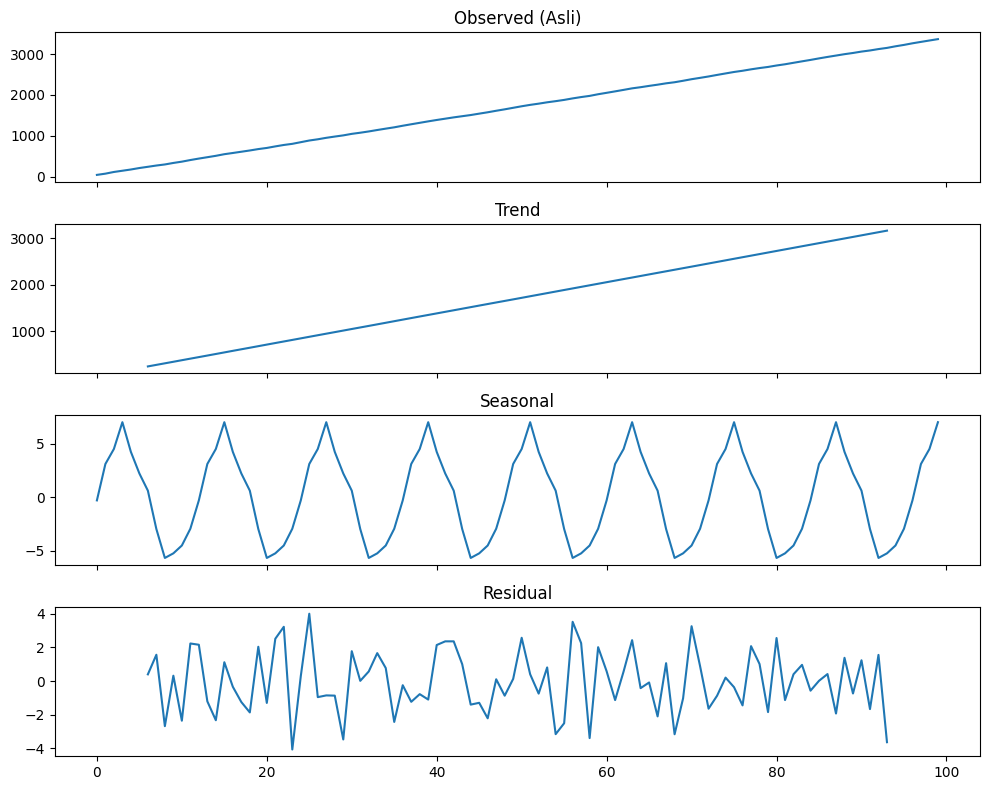

In [116]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


### Interpretasi dekomposisi tren linear + seasonal

**Observed** memperlihatkan deret yang meningkat dan berfluktuasi secara periodik. **Trend** menangkap kenaikan jangka panjang. **Seasonal** menunjukkan pola yang berulang setiap 12 observasi, sesuai dengan komponen sinusoidal yang digunakan saat simulasi. **Residual** merupakan variasi yang tersisa setelah trend dan seasonal dipisahkan.

Karena data simulasi dibangkitkan sebagai penjumlahan trend + seasonal + noise, dekomposisi **aditif** sesuai dengan struktur pembangkit data.


1. Observed (data asli)
Grafik Observed menunjukkan bahwa nilai deret waktu secara umum mengalami peningkatan dari waktu ke waktu.

2. Trend
Komponen Trend menunjukkan pola yang sangat jelas, yaitu meningkat hampir secara linear. Bentuk tren juga tidak menunjukkan pola kuadratik yang kuat.

3. Seasonal
Komponen Seasonal menunjukkan pola yang berulang secara sangat teratur.

4. Residual
Komponen Residual berfluktuasi di sekitar nilai nol.

### Aditif vs multiplikatif

Ada dua bentuk utama dekomposisi:

- **Aditif:** $Y_t=T_t+S_t+R_t$. Efek seasonal relatif konstan dalam satuan absolut.
- **Multiplikatif:** $Y_t=T_t S_t R_t$. Efek seasonal relatif terhadap level deret; ketika level meningkat, amplitudo seasonal cenderung ikut meningkat.

Jadi, bukan "ragam kecil = aditif" dan "ragam besar = multiplikatif" secara otomatis. Yang diperhatikan adalah **apakah amplitudo fluktuasi seasonal bergantung pada level deret**.


In [119]:
# Simulasi deret dengan seasonal multiplikatif
np.random.seed(1033)
n = 100
x = np.arange(n)

# Trend linear positif
beta0 = 33+10.0
beta1 = 33+0.05
trend_multi = beta0 + beta1*x

# Faktor seasonal: 1 +/- 0.5 (50% dari level trend)
seasonality_multi = 1 + 0.5*np.sin(2*np.pi*x/12)

# Error aditif kecil untuk simulasi ilustratif
noise_multi = np.random.normal(scale=0.2, size=n)
series_multi = trend_multi*seasonality_multi + noise_multi


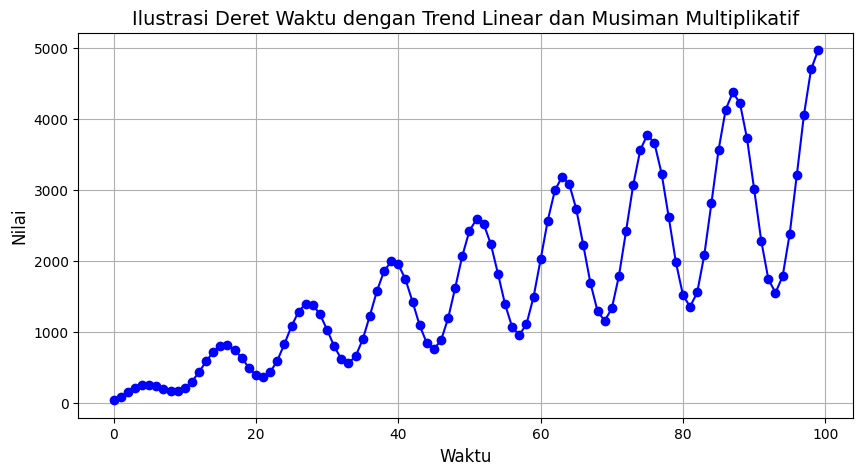

In [120]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Model multiplikatif membuat pola amplitudo pola musiman tampak semakin besar ketika level deret meningkat.

In [121]:
df_multi = pd.DataFrame({'Period': x, 'Value': series_multi})
result_multi = seasonal_decompose(
    df_multi['Value'],
    model='multiplicative',
    period=12
)


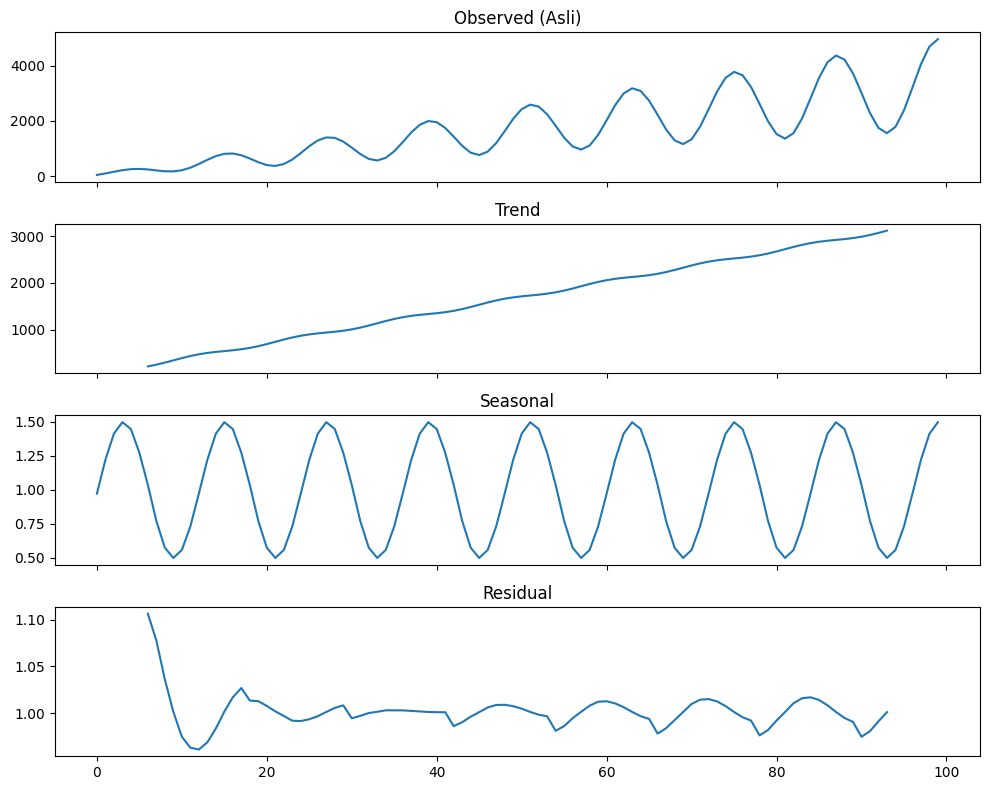

In [122]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

### Interpretasi dekomposisi multiplikatif

Pada deret multiplikatif, amplitudo fluktuasi seasonal meningkat ketika level trend meningkat. Hal ini terjadi karena seasonal berperan sebagai **faktor pengali**. Misalnya, faktor seasonal $1.5$ berarti nilai sekitar 50% di atas trend, sedangkan $0.5$ berarti sekitar 50% di bawah trend.

Implikasinya untuk pemodelan adalah efek seasonal tidak konstan dalam satuan absolut. Karena itu, model forecasting dapat menggunakan bentuk multiplikatif seperti Holt--Winters multiplicative, atau transformasi log bila struktur dan asumsi error mendukung.


In [125]:
# Simulasi deret tanpa trend dan tanpa seasonal: hanya noise di sekitar level 10
np.random.seed(1033)
n = 100
x = np.arange(n)
noise = np.random.normal(loc=10, scale=2, size=n)
df_no_trend = pd.DataFrame({'Period': x, 'Series': noise})


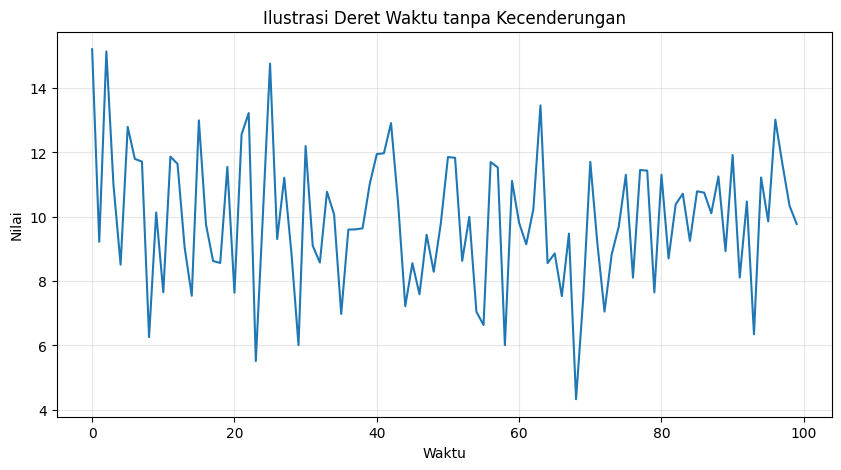

In [126]:
plt.figure(figsize=(10, 5))
plt.plot(df_no_trend['Period'], df_no_trend['Series'])
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan')
plt.grid(alpha=0.3)
plt.show()


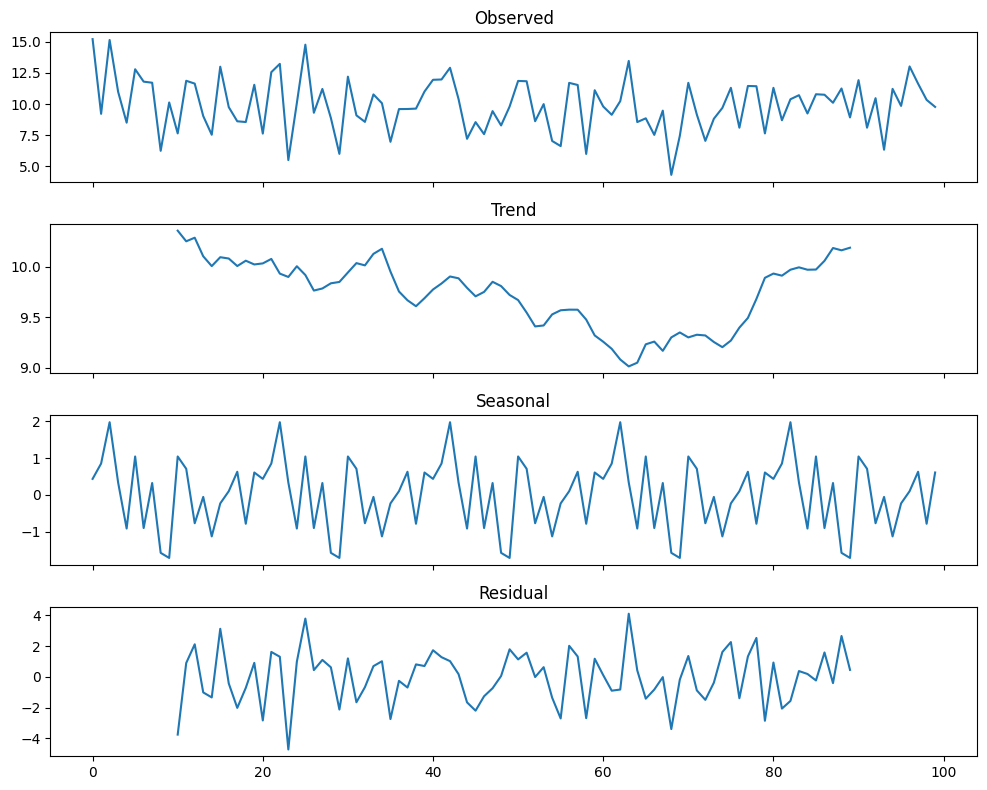

In [127]:
# Dekomposisi aditif untuk ilustrasi deret tanpa trend/seasonal
result_no_trend = seasonal_decompose(
    df_no_trend['Series'],
    model='additive',
    period=20
)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_no_trend.observed.plot(ax=axes[0], title='Observed')
result_no_trend.trend.plot(ax=axes[1], title='Trend')
result_no_trend.seasonal.plot(ax=axes[2], title='Seasonal')
result_no_trend.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()


### Interpretasi dekomposisi deret tanpa kecenderungan

**Observed** berfluktuasi di sekitar level sekitar 10 tanpa tren naik atau turun yang kuat. **Trend** cenderung mendekati level konstan. Karena data simulasi sebenarnya hanya mengandung noise dan tidak memiliki seasonal, komponen seasonal yang muncul dari dekomposisi tidak boleh langsung dianggap sebagai bukti adanya seasonal; dengan data acak, metode dekomposisi tetap dapat menghasilkan pola seasonal estimasi.

Dengan demikian, untuk menyimpulkan ada/tidaknya seasonal,diperlukan kombinasi pembangkitan data, plot, ACF, dan diagnosis residual, tidak hanya mengandalkan  grafik dekomposisi semata.


## Kesimpulan Umum

Dekomposisi membantu mengidentifikasi struktur deret waktu menjadi trend, seasonal, dan residual. Hasil dekomposisi kemudian dapat digunakan sebagai **dasar eksplorasi untuk memilih model kandidat**.

- Tidak ada trend/seasonal yang jelas → model level sederhana dapat dipertimbangkan.
- Ada trend → regresi trend, Holt, atau model lain yang menangkap trend.
- Ada seasonal → dummy musiman, regresi harmonik/Fourier, Holt--Winters, atau SARIMA.
- Ada trend + seasonal → model yang menangkap kedua komponen tersebut.
- Seasonal beramplitudo relatif konstan → pertimbangkan struktur aditif.
- Amplitudo seasonal mengikuti level → pertimbangkan struktur multiplikatif atau transformasi yang sesuai.

Setelah model dipasang, parameter **diestimasi dari data** (misalnya OLS untuk regresi), lalu residual diperiksa melalui uji heteroskedastisitas, autokorelasi, dan normalitas. Untuk simulasi, parameter pembangkit diketahui terlebih dahulu sehingga hasil estimasi dapat dibandingkan dengan parameter sebenarnya.
